<a href="https://colab.research.google.com/github/mathivathani-1411/mathivathani-codebooster-2026/blob/main/Day4/MiniProject_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark --quiet
print('Pyspark installation complete!')

Pyspark installation complete!


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


#SparkSession
spark=SparkSession.builder \
.appName('Day4_BigData_Sales')\
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()


print(f'Spark Session : {spark.version}')

Spark Session : 4.0.2


In [5]:
df_bronze = spark.read \
.option('header','true') \
.option('inferSchema','true') \
.csv('large_sales_data.csv')

print('BRONZE LAYER-Raw Data')
print(f'Rows : {df_bronze.count()}')
print(f'Columns : {len(df_bronze.columns)}')
print(f'Names : {df_bronze.columns}')

print()
df_bronze.printSchema()

BRONZE LAYER-Raw Data
Rows : 5000
Columns : 13
Names : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [6]:
from pyspark.sql.functions import col, to_date, year, month
import pyspark.sql.functions as F

df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id', 'product', 'revenue'])

df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'), 'dd-MM-yyyy')
)

df_silver = df_silver \
    .withColumn('order_year', year(col('order_date'))) \
    .withColumn('order_month', month(col('order_date')))

df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue') > 40000, 'High')
     .when(col('revenue') > 10000, 'Medium')
     .otherwise('Low')
)

print(f'Silver layer rows : {df_silver.count()}')
print('New columns added : order_year, order_month, revenue_category')

df_silver.select(
    'product', 'revenue', 'order_year', 'order_month', 'revenue_category'
).show(8)

Silver layer rows : 5000
New columns added : order_year, order_month, revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|          Medium|
|    Webcam|  35000|      2023|         11|          Medium|
|    Laptop| 360000|      2023|          1|            High|
+----------+-------+----------+-----------+----------------+
only showing top 8 rows


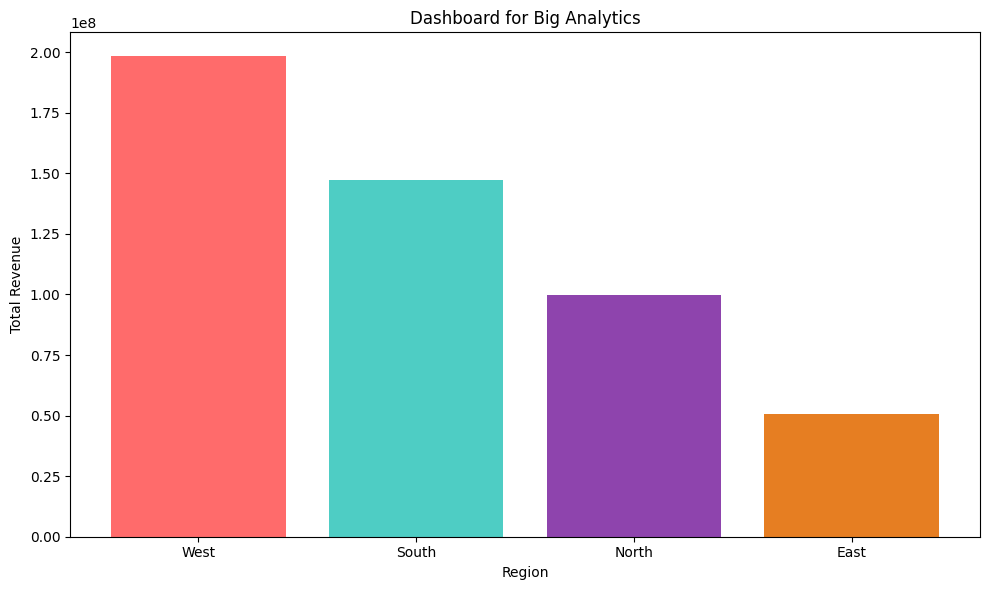

In [15]:

import matplotlib.pyplot as plt

region_revenue = df_silver \
    .groupBy('region') \
    .agg(F.sum('revenue').alias('total_revenue')
    ) \
    .orderBy('total_revenue', ascending=False)

region_revenue_pd = region_revenue.toPandas()

colors = ['#FF6B6B', '#4ECDC4', '#8E44AD', '#E67E22']

plt.figure(figsize=(10, 6))
plt.bar(
    region_revenue_pd['region'],
    region_revenue_pd['total_revenue'],
    color=colors
)

plt.title('Dashboard for Big Analytics')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()